# Credit Risk Modeling Using LendingClub Data: A Comprehensive Framework for PD, LGD, EAD, and Scorecard Development.

---

# Objective

- Build a complete credit risk modeling pipeline using LendingClub loan data.
- Estimate three key risk parameters:
  - **Probability of Default (PD)**
  - **Loss Given Default (LGD)**
  - **Exposure at Default (EAD)**
- Compute:
  - **Expected Loss (EL)**
  - **Credit Value at Risk (Credit VaR)**
- Develop a **credit scorecard** for decision-making.

---

# Dataset Overview

- **Source:** LendingClub (2007–2018), available at https://www.kaggle.com/datasets/wordsforthewise/lending-club/data.
- **Final size after preprocessing:** ~1 million loans
- **Included features:**
  - Loan amount, term, interest rate, installment, Grade, sub-grade, employment length, income, DTI, delinquencies, inquiries, account data, Purpose, state, home ownership
- **Target variables:**
  - `default`: binary (1 = Charged Off, 0 = Fully Paid)
  - `lgd`: (loan amount - recoveries) / loan amount
  - `ead`: funded amount

---

# Methodology

## Data Preprocessing

- Kept only "Fully Paid" and "Charged Off" loans
- Created `default`, `lgd`, and `ead` columns
- Filled missing values using median or 'Unknown'
- Encoded categorical features (OrdinalEncoder, OneHotEncoder)
- Standardized numeric features
- Derived new feature: `months_since_issue`

---

## PD Modeling

- **Features used:** 13 numeric + 6 categorical
- **Models tested:**
  - Logistic Regression
  - Random Forest Classifier
  - XGBoost Classifier
- **Best model:** XGBoost
  - AUC = 0.9175
  - Brier Score = 0.057
  - F1 Score = 0.80
- Used ROC curve and classification report for evaluation

---

## LGD Modeling

- Used only **defaulted loans** (`default == 1`)
- **Models tested:**
  - Linear Regression
  - Random Forest Regressor
- **Best model:** Random Forest
  - R² = 0.999
  - RMSE $\approx$ 0.003
- Included `recoveries` as a feature

---

## EAD Modeling

- Used only **defaulted loans**
- Excluded `funded_amnt` and `recoveries` from features
- **Models tested:**
  - Linear Regression
  - Random Forest Regressor
  - XGBoost Regressor
- **Best model:** Random Forest
  - R² = 0.999
  - RMSE $\approx$ 58.7

---

## Expected Loss and Credit VaR

- Used:
  - Logistic Regression for PD
  - Linear Regression for LGD and EAD
  - Monte Carlo simulation for loss distribution
- Calculated:
  - **Expected Loss (EL):** $\approx$ 2.91 billion
  - **99% Credit VaR:** $\approx$ 2.92 billion
  - **Unexpected Loss:** $\approx$ 10.7 million
- Simulation vs analytical EL error: **< 0.001%**

---

## Scorecard Development

- Used `scorecardpy` for WoE binning
- Trained Logistic Regression on WoE features
- Generated scores using base score and PDO
- Binned scores into deciles and computed default rates
- Optimal cutoff: **Score = 650**
  - Recall $\approx$ 90%
  - Approval rate $\approx$ 30%
- Simulated policy impacts at different cutoffs

---

# Key Achievements

- Built an end-to-end risk modeling pipeline using real data
- Designed and evaluated high-performance models for PD, LGD, and EAD
- Generated accurate portfolio risk metrics (EL and Credit VaR)
- Built an interpretable and effective credit scorecard
- Simulated real-world loan decisioning policies

---

# Conclusion

- Successfully demonstrated a full credit risk modeling pipeline
- Models performed well on both prediction and interpretability
- Scorecard offers actionable insights for loan approval
- Portfolio risk can be quantified using simulation and analytics

---

# Code


Required libraries

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC
from xgboost import XGBClassifier, XGBRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve,
    classification_report, ConfusionMatrixDisplay, brier_score_loss, mean_squared_error, r2_score)

from scorecardpy import woebin, woebin_plot, woebin_ply


import warnings
warnings.filterwarnings("ignore")

## Data preparation:

The credit dataset used in this project was downloaded from Kaggle's Lending Club dataset https://www.kaggle.com/datasets/wordsforthewise/lending-club/data. Due to the large size of the original data files, the dataset was processed in manageable chunk sizes, allowing for efficient memory usage and analysis on a standard personal computer. Additionally, only a subset of relevant columns and approx 10 million entries was selected for the analysis to focus on key features and to further optimize performance.

In [2]:
input_path = "accepted_2007_to_2018Q4.csv"
output_path = "lendingclub_preprocessed.csv"

# Relevant loan_status values
valid_status = ["Fully Paid", "Charged Off"]

# Columns to keep
columns = [
    'loan_amnt', 'funded_amnt', 'term', 'int_rate', 'installment', 'grade',
    'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'purpose',
    'addr_state', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc',
    'revol_util', 'total_acc', 'recoveries', 'loan_status', 'issue_d'
]

# Initialize empty list for chunks
chunks = []

# Process in chunks
for chunk in pd.read_csv(input_path, usecols=columns, chunksize=50000):
    chunk = chunk[chunk['loan_status'].isin(valid_status)]
    chunk = chunk.dropna(subset=['loan_amnt', 'funded_amnt', 'recoveries'])

    # Create default label
    chunk['default'] = chunk['loan_status'].map({'Charged Off': 1, 'Fully Paid': 0})

    # Create LGD and EAD
    chunk['lgd'] = 0.0
    idx_default = (chunk['default'] == 1)
    lgd_values = (chunk.loc[idx_default, 'loan_amnt'] - chunk.loc[idx_default, 'recoveries']) / chunk.loc[idx_default, 'loan_amnt']
    chunk.loc[idx_default, 'lgd'] = lgd_values.clip(lower=0, upper=1)

    chunk['ead'] = chunk['funded_amnt']
    
    

    chunks.append(chunk)

    # Stop early if file gets too big
    if sum(len(c) for c in chunks) > 1000000:
        break



final_df = pd.concat(chunks)
final_df = final_df.drop(columns=['loan_status'])  # Drop original status
final_df.to_csv(output_path, index=False)
print(f"Saved cleaned dataset with {len(final_df)} rows to {output_path}")


Saved cleaned dataset with 1004218 rows to lendingclub_preprocessed.csv


In [3]:
df = pd.read_csv("lendingclub_preprocessed.csv")

In [4]:
pd.options.display.max_columns = None
df.head()

,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,issue_d,purpose,addr_state,dti,delinq_2yrs,inq_last_6mths,open_acc,revol_util,total_acc,recoveries,default,lgd,ead
0,3600.0,3600.0,36 months,13.99,123.03,C,C4,10+ years,MORTGAGE,55000.0,Dec-2015,debt_consolidation,PA,5.91,0.0,1.0,7.0,29.7,13.0,0.0,0,0.0,3600.0
1,24700.0,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,65000.0,Dec-2015,small_business,SD,16.06,1.0,4.0,22.0,19.2,38.0,0.0,0,0.0,24700.0
2,20000.0,20000.0,60 months,10.78,432.66,B,B4,10+ years,MORTGAGE,63000.0,Dec-2015,home_improvement,IL,10.78,0.0,0.0,6.0,56.2,18.0,0.0,0,0.0,20000.0
3,10400.0,10400.0,60 months,22.45,289.91,F,F1,3 years,MORTGAGE,104433.0,Dec-2015,major_purchase,PA,25.37,1.0,3.0,12.0,64.5,35.0,0.0,0,0.0,10400.0
4,11950.0,11950.0,36 months,13.44,405.18,C,C3,4 years,RENT,34000.0,Dec-2015,debt_consolidation,GA,10.20,0.0,0.0,5.0,68.4,6.0,0.0,0,0.0,11950.0


In [5]:
df.isnull().sum().sort_values(ascending=False)

emp_length        60505
revol_util          582
dti                 290
inq_last_6mths        1
loan_amnt             0
funded_amnt           0
term                  0
sub_grade             0
grade                 0
installment           0
int_rate              0
issue_d               0
purpose               0
annual_inc            0
home_ownership        0
delinq_2yrs           0
addr_state            0
open_acc              0
total_acc             0
recoveries            0
default               0
lgd                   0
ead                   0
dtype: int64

In [6]:
# fixing missing dti (Debt-to-Income Ratio) rows
df['dti'].fillna(df['dti'].median(), inplace=True)

# fixing missing emp_length (Employee Length) rows
#df['emp_length'] = df['emp_length'].fillna('Unknown')
df['emp_length'].fillna('Unknown', inplace=True)


# fixing missing revol_util (Revolving Utilization) rows
#df['revol_util'] = df['revol_util'].fillna(df['revol_util'].median())
df['revol_util'].fillna(df['revol_util'].median(), inplace=True)

df.dropna(inplace=True)


In [7]:
df.isnull().any().sum()

0

In [8]:
print("Dataset Shape:")
print(df.shape)
print("\n Data Info:")
print(df.info())
print("\n Descriptive Statistics:")
print(df.describe())

Dataset Shape:
(1004217, 23)

 Data Info:
<class 'pandas.core.frame.DataFrame'>
Index: 1004217 entries, 0 to 1004217
Data columns (total 23 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   loan_amnt       1004217 non-null  float64
 1   funded_amnt     1004217 non-null  float64
 2   term            1004217 non-null  object 
 3   int_rate        1004217 non-null  float64
 4   installment     1004217 non-null  float64
 5   grade           1004217 non-null  object 
 6   sub_grade       1004217 non-null  object 
 7   emp_length      1004217 non-null  object 
 8   home_ownership  1004217 non-null  object 
 9   annual_inc      1004217 non-null  float64
 10  issue_d         1004217 non-null  object 
 11  purpose         1004217 non-null  object 
 12  addr_state      1004217 non-null  object 
 13  dti             1004217 non-null  float64
 14  delinq_2yrs     1004217 non-null  float64
 15  inq_last_6mths  1004217 non-null  float64
 16 

In [9]:
for col in df.select_dtypes(include='object').columns:
    print(f"Unique entries in the column \"{col }\" is {df[col].unique()}")

Unique entries in the column "term" is [' 36 months' ' 60 months']
Unique entries in the column "grade" is ['C' 'B' 'F' 'A' 'E' 'D' 'G']
Unique entries in the column "sub_grade" is ['C4' 'C1' 'B4' 'F1' 'C3' 'B2' 'B1' 'A2' 'B5' 'C2' 'E2' 'A4' 'E3' 'C5'
 'A1' 'D4' 'F3' 'D1' 'B3' 'D3' 'D5' 'A5' 'F2' 'E4' 'D2' 'E1' 'F5' 'E5'
 'A3' 'G2' 'G1' 'G3' 'G4' 'F4' 'G5']
Unique entries in the column "emp_length" is ['10+ years' '3 years' '4 years' '6 years' '7 years' '8 years' '2 years'
 '5 years' '9 years' '< 1 year' '1 year' 'Unknown']
Unique entries in the column "home_ownership" is ['MORTGAGE' 'RENT' 'OWN' 'ANY' 'NONE' 'OTHER']
Unique entries in the column "issue_d" is ['Dec-2015' 'Nov-2015' 'Oct-2015' 'Sep-2015' 'Aug-2015' 'Jul-2015'
 'Jun-2015' 'May-2015' 'Apr-2015' 'Mar-2015' 'Feb-2015' 'Jan-2015'
 'Mar-2018' 'Feb-2018' 'Jan-2018' 'Sep-2017' 'Aug-2017' 'Jul-2017'
 'Jun-2016' 'May-2016' 'Apr-2016' 'Sep-2018' 'Aug-2018' 'Jul-2018'
 'Jun-2017' 'May-2017' 'Apr-2017' 'Mar-2016' 'Feb-2016' 'Jan-201

In [10]:
# Define mappings
emp_length_map = {'< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3, '4 years': 4,
                  '5 years': 5, '6 years': 6, '7 years': 7, '8 years': 8,
                  '9 years': 9, '10+ years': 10, 'Unknown': -1}

# Preprocessing functions
df['term'] = df['term'].str.extract('(\d+)').astype(int)
df['emp_length'] = df['emp_length'].map(emp_length_map)



In [11]:
df['issue_d_dt'] = pd.to_datetime(df['issue_d'], format='%b-%Y')

# Define a reference date
reference_date = pd.to_datetime('Dec-2018', format='%b-%Y')

# Step 3: Calculate month difference
df['months_since_issue'] = (reference_date.year - df['issue_d_dt'].dt.year) * 12 + (reference_date.month - df['issue_d_dt'].dt.month)
df.drop(columns=["issue_d","issue_d_dt"],inplace=True)

In [12]:
sum(df['loan_amnt']!=df['funded_amnt'])

1856

Since `loan_amnt` and `funded_amnt` are almost equal except a few rows, we drop the 'loan_amnt' column.

In [13]:
df.drop(columns=['loan_amnt'], inplace=True)

In [14]:
ordinal_features = ['grade', 'sub_grade', 'emp_length']
nominal_features = ['purpose', 'addr_state', 'home_ownership']
numeric_features = [
     'funded_amnt', 'int_rate', 'installment', 'annual_inc',
    'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'revol_util',
    'total_acc', 'recoveries', 'term', 'months_since_issue'
]


In [15]:
df.head()

,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,purpose,addr_state,dti,delinq_2yrs,inq_last_6mths,open_acc,revol_util,total_acc,recoveries,default,lgd,ead,months_since_issue
0,3600.0,36,13.99,123.03,C,C4,10,MORTGAGE,55000.0,debt_consolidation,PA,5.91,0.0,1.0,7.0,29.7,13.0,0.0,0,0.0,3600.0,36
1,24700.0,36,11.99,820.28,C,C1,10,MORTGAGE,65000.0,small_business,SD,16.06,1.0,4.0,22.0,19.2,38.0,0.0,0,0.0,24700.0,36
2,20000.0,60,10.78,432.66,B,B4,10,MORTGAGE,63000.0,home_improvement,IL,10.78,0.0,0.0,6.0,56.2,18.0,0.0,0,0.0,20000.0,36
3,10400.0,60,22.45,289.91,F,F1,3,MORTGAGE,104433.0,major_purchase,PA,25.37,1.0,3.0,12.0,64.5,35.0,0.0,0,0.0,10400.0,36
4,11950.0,36,13.44,405.18,C,C3,4,RENT,34000.0,debt_consolidation,GA,10.20,0.0,0.0,5.0,68.4,6.0,0.0,0,0.0,11950.0,36


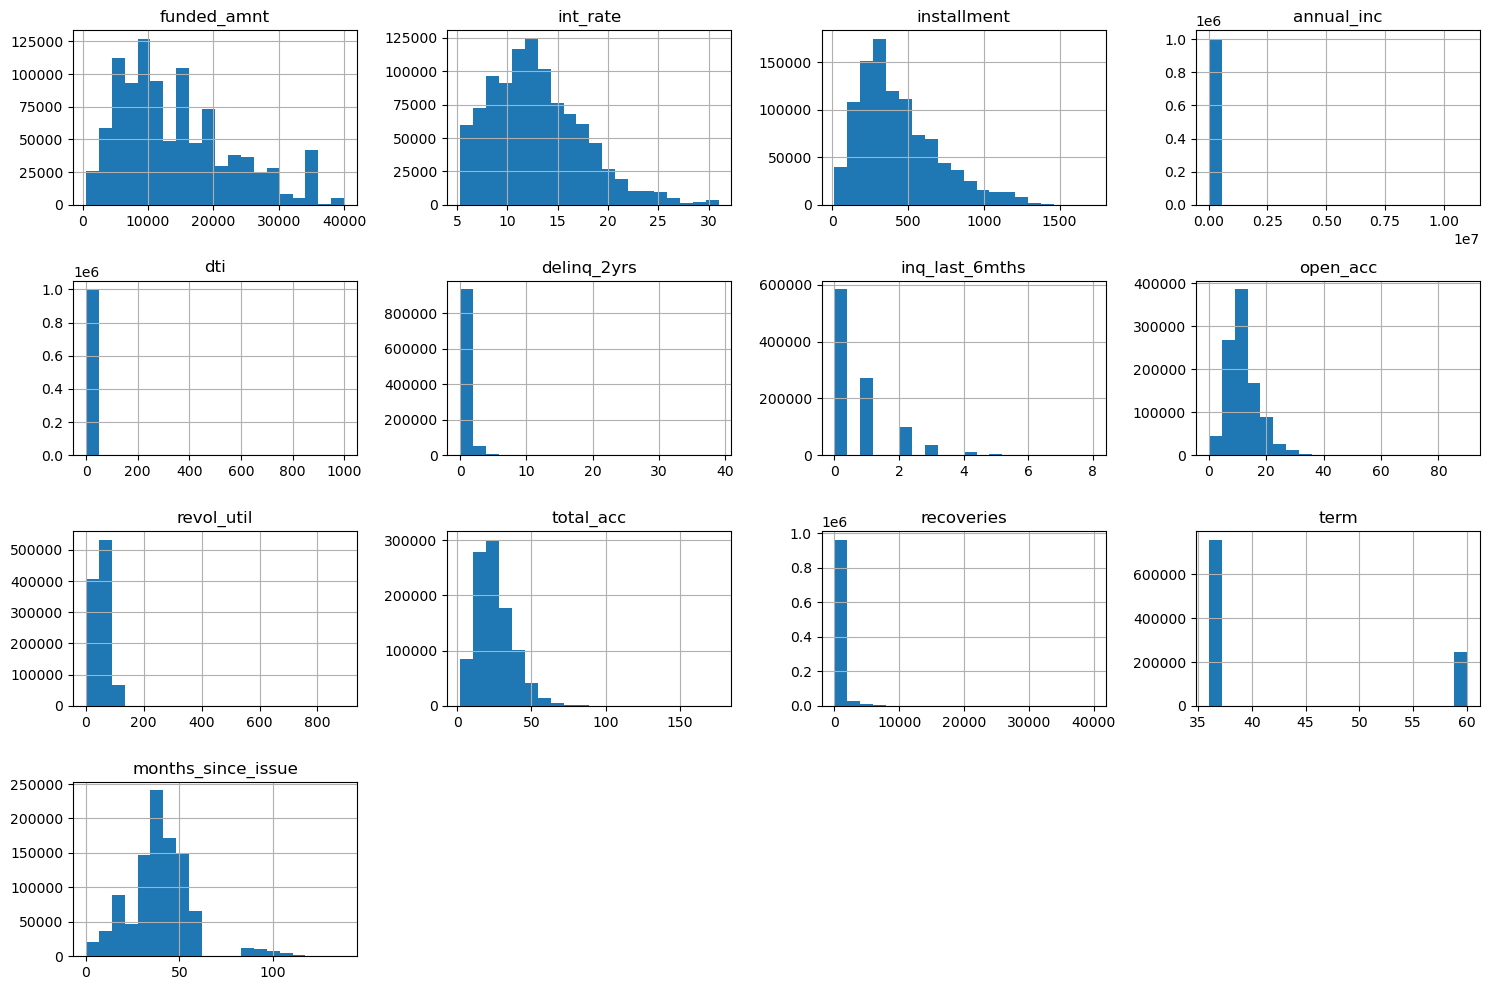

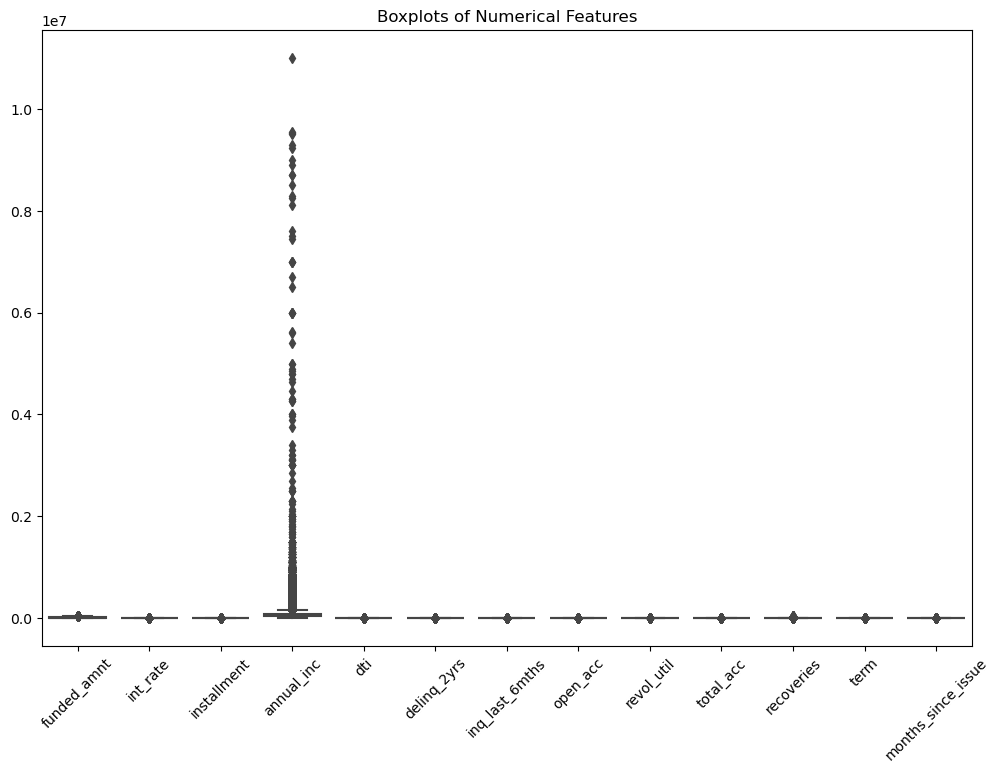

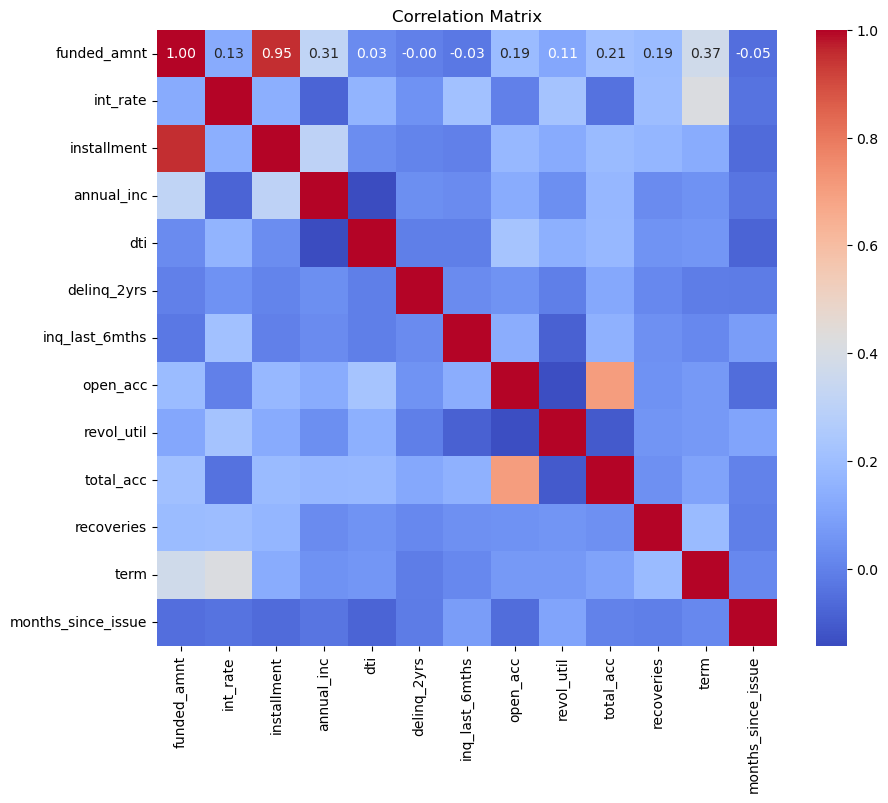

In [16]:
# Histograms for numerical features
df[numeric_features].hist(bins=20, figsize=(15, 10))
plt.tight_layout()
plt.show()

# Boxplots to detect outliers
plt.figure(figsize=(12, 8))
sns.boxplot(data=df[numeric_features])
plt.xticks(rotation=45)
plt.title("Boxplots of Numerical Features")
plt.show()

# Correlation Matrix
plt.figure(figsize=(10, 8))
corr = df[numeric_features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


Column: grade
grade
B    284031
C    283084
A    186880
D    147905
E     72289
F     23054
G      6974
Name: count, dtype: int64


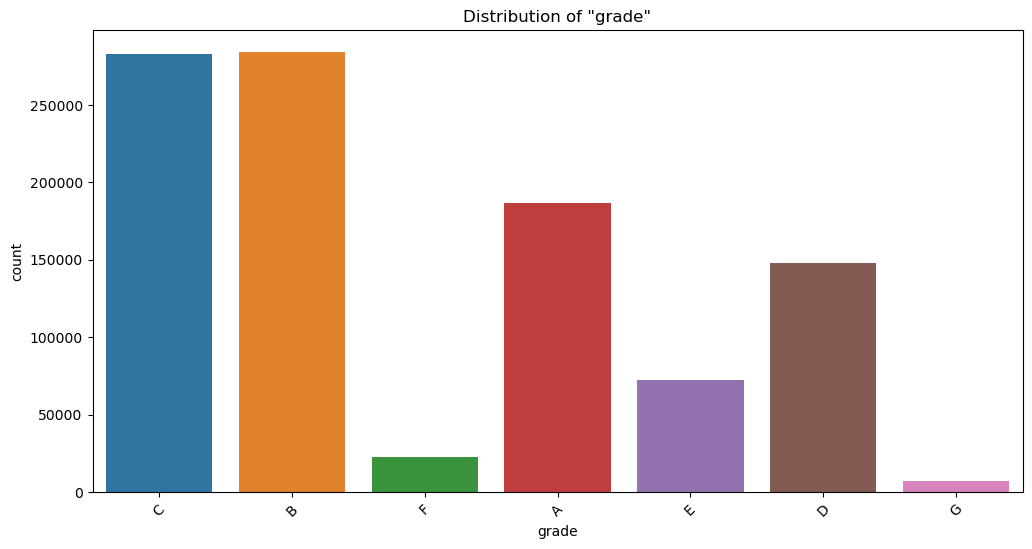

Column: sub_grade
sub_grade
C1    63027
B5    61557
B4    59303
C2    59141
B3    57988
C3    56166
C4    55087
B2    53134
B1    52049
A5    50787
C5    49663
A4    41176
D1    38210
A1    36031
D2    32529
A2    29502
A3    29384
D3    29270
D4    26125
D5    21771
E1    18725
E2    16734
E3    14046
E4    11764
E5    11020
F1     7345
F2     5132
F3     4348
F4     3479
F5     2750
G1     2166
G2     1623
G3     1246
G4     1012
G5      927
Name: count, dtype: int64


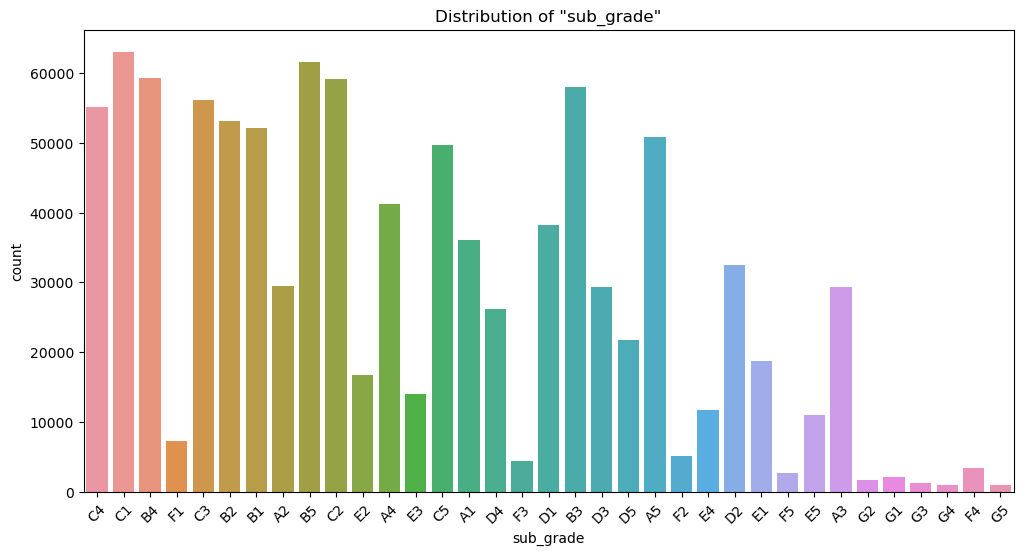

Column: emp_length
emp_length
 10    329685
 2      91352
 0      82316
 3      81351
 1      66595
-1      60505
 4      60501
 5      60400
 8      46024
 6      43937
 7      43378
 9      38173
Name: count, dtype: int64


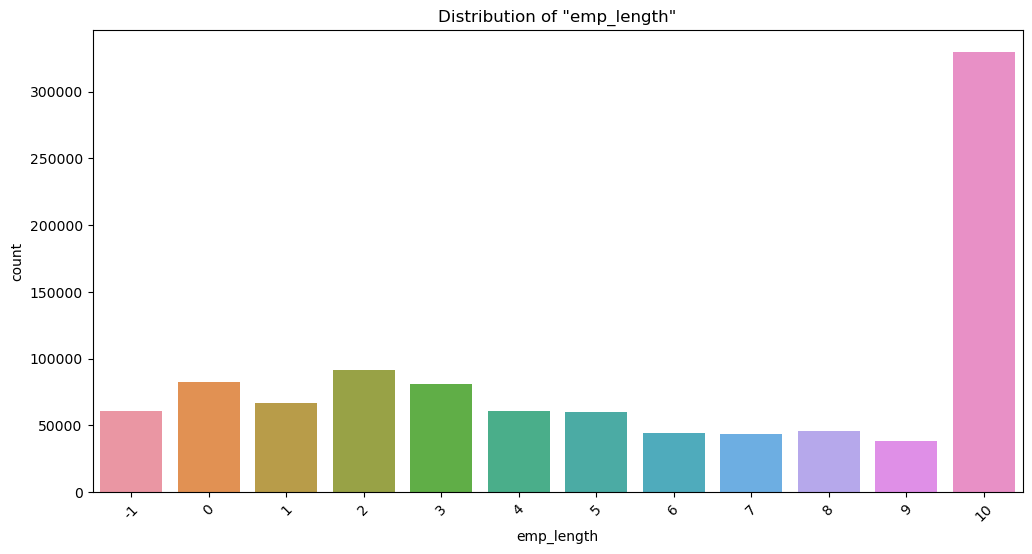

Column: purpose
purpose
debt_consolidation    580506
credit_card           223831
home_improvement       66001
other                  57277
major_purchase         21910
medical                11857
small_business         10977
car                    10834
moving                  7150
vacation                6866
house                   5038
wedding                  962
renewable_energy         682
educational              326
Name: count, dtype: int64


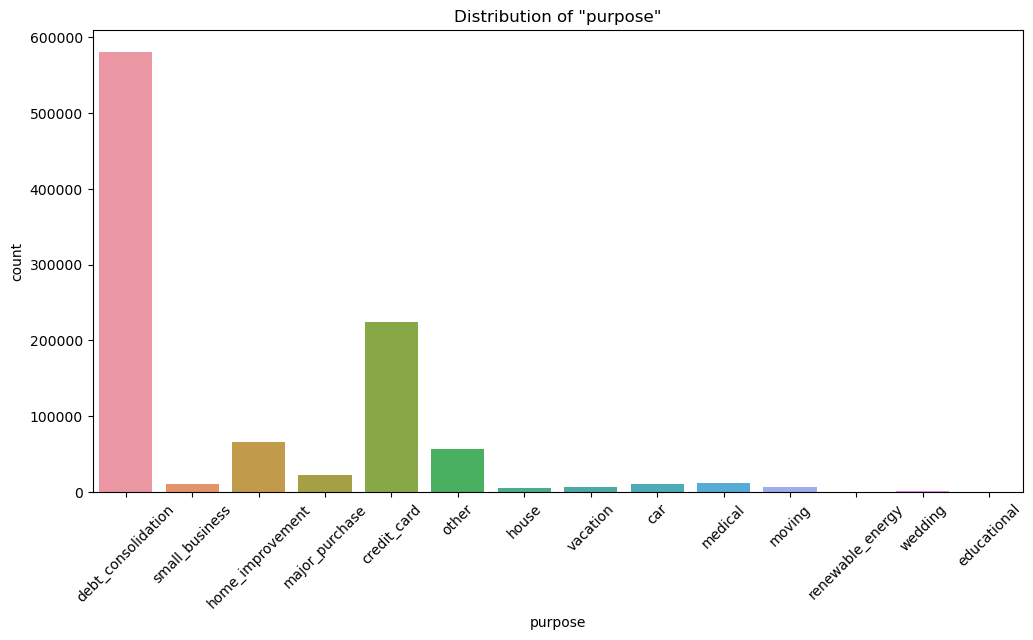

Column: addr_state
addr_state
CA    144145
TX     82617
NY     81476
FL     71098
IL     38865
NJ     35986
PA     34062
OH     33070
GA     32556
VA     28369
NC     28055
MI     26585
AZ     24339
MD     23383
MA     23110
CO     22195
WA     21668
MN     18102
IN     16726
MO     15885
TN     15808
NV     15000
CT     14618
WI     13380
AL     12410
OR     12114
SC     12044
LA     11588
KY      9646
OK      9205
KS      8263
AR      7454
UT      7382
MS      5657
NM      5604
HI      4887
NH      4856
RI      4385
WV      3869
DE      2849
MT      2842
NE      2816
DC      2532
AK      2342
WY      2160
SD      2064
VT      2060
ME      1597
ND      1275
ID      1212
IA         6
Name: count, dtype: int64


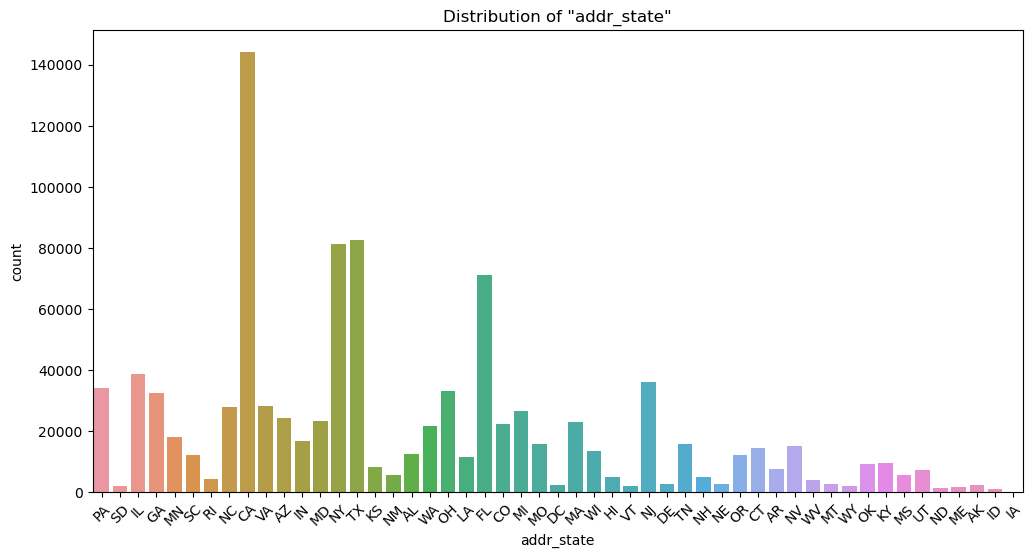

Column: home_ownership
home_ownership
MORTGAGE    493867
RENT        399464
OWN         110561
ANY            221
OTHER           98
NONE             6
Name: count, dtype: int64


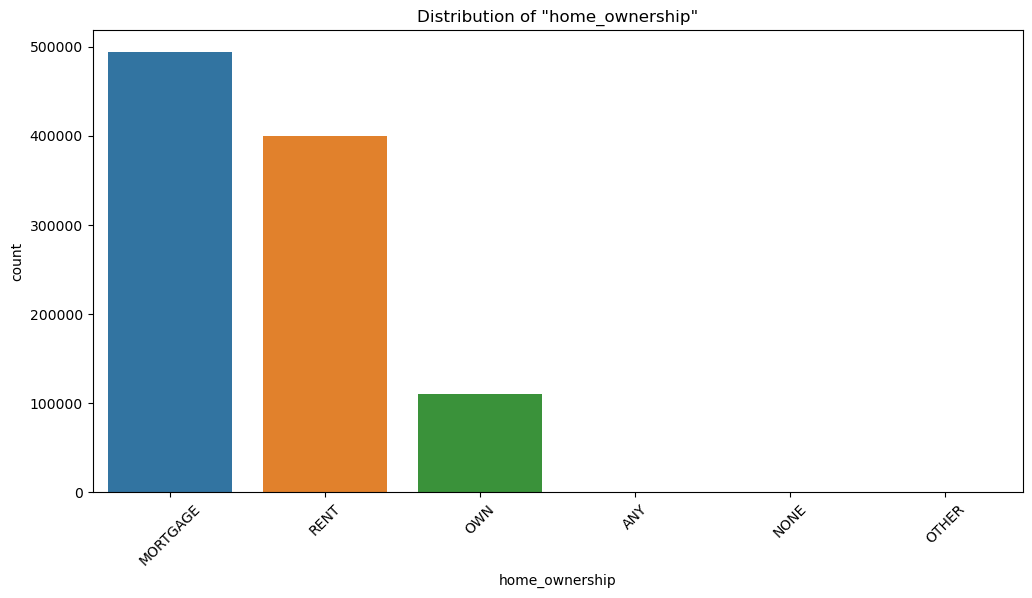

In [17]:
# For each categorical column, print unique values and frequency counts
for col in ordinal_features+nominal_features:
    print(f"Column: {col}")
    print(df[col].value_counts())
    plt.figure(figsize=(12, 6))
    sns.countplot(data=df, x=col)
    plt.title(f"Distribution of \"{col}\"")
    plt.xticks(rotation=45)
    plt.show()


In [18]:
purpose_counts = df['purpose'].value_counts()
common_purposes = purpose_counts[purpose_counts >= 10000].index
df['purpose'] = df['purpose'].where(df['purpose'].isin(common_purposes), 'rare')

state_counts = df['addr_state'].value_counts()
sufficient_states = state_counts[state_counts >= 10000].index
df['addr_state'] = df['addr_state'].where(df['addr_state'].isin(sufficient_states), 'OTHER')



df = df[df['home_ownership'].isin(['MORTGAGE', 'RENT', 'OWN'])]


default
0    802051
1    201841
Name: count, dtype: int64
Ratio of default to non default = 25.17%


<Axes: xlabel='default'>

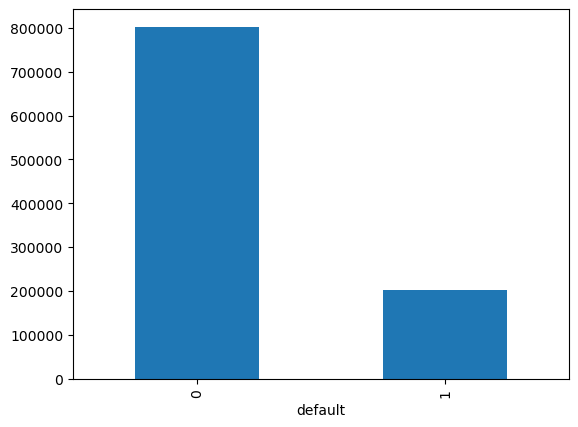

In [19]:
print(df['default'].value_counts())
print(f"Ratio of default to non default = {(df['default'].value_counts()[1]/df['default'].value_counts()[0])*100:.2f}%")

df['default'].value_counts().plot(kind='bar')

In [20]:
df.head()

,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,purpose,addr_state,dti,delinq_2yrs,inq_last_6mths,open_acc,revol_util,total_acc,recoveries,default,lgd,ead,months_since_issue
0,3600.0,36,13.99,123.03,C,C4,10,MORTGAGE,55000.0,debt_consolidation,PA,5.91,0.0,1.0,7.0,29.7,13.0,0.0,0,0.0,3600.0,36
1,24700.0,36,11.99,820.28,C,C1,10,MORTGAGE,65000.0,small_business,OTHER,16.06,1.0,4.0,22.0,19.2,38.0,0.0,0,0.0,24700.0,36
2,20000.0,60,10.78,432.66,B,B4,10,MORTGAGE,63000.0,home_improvement,IL,10.78,0.0,0.0,6.0,56.2,18.0,0.0,0,0.0,20000.0,36
3,10400.0,60,22.45,289.91,F,F1,3,MORTGAGE,104433.0,major_purchase,PA,25.37,1.0,3.0,12.0,64.5,35.0,0.0,0,0.0,10400.0,36
4,11950.0,36,13.44,405.18,C,C3,4,RENT,34000.0,debt_consolidation,GA,10.20,0.0,0.0,5.0,68.4,6.0,0.0,0,0.0,11950.0,36


## PD modeling


 Logistic Regression : 
              precision    recall  f1-score   support

           0     0.9199    0.9996    0.9581    160411
           1     0.9974    0.6541    0.7901     40368

    accuracy                         0.9301    200779
   macro avg     0.9586    0.8268    0.8741    200779
weighted avg     0.9355    0.9301    0.9243    200779


 Random Forest : 
              precision    recall  f1-score   support

           0     0.9230    0.9997    0.9598    160411
           1     0.9984    0.6687    0.8009     40368

    accuracy                         0.9332    200779
   macro avg     0.9607    0.8342    0.8804    200779
weighted avg     0.9382    0.9332    0.9279    200779


 XGBoost : 
              precision    recall  f1-score   support

           0     0.9230    0.9992    0.9596    160411
           1     0.9953    0.6688    0.8000     40368

    accuracy                         0.9328    200779
   macro avg     0.9591    0.8340    0.8798    200779
weighted avg     

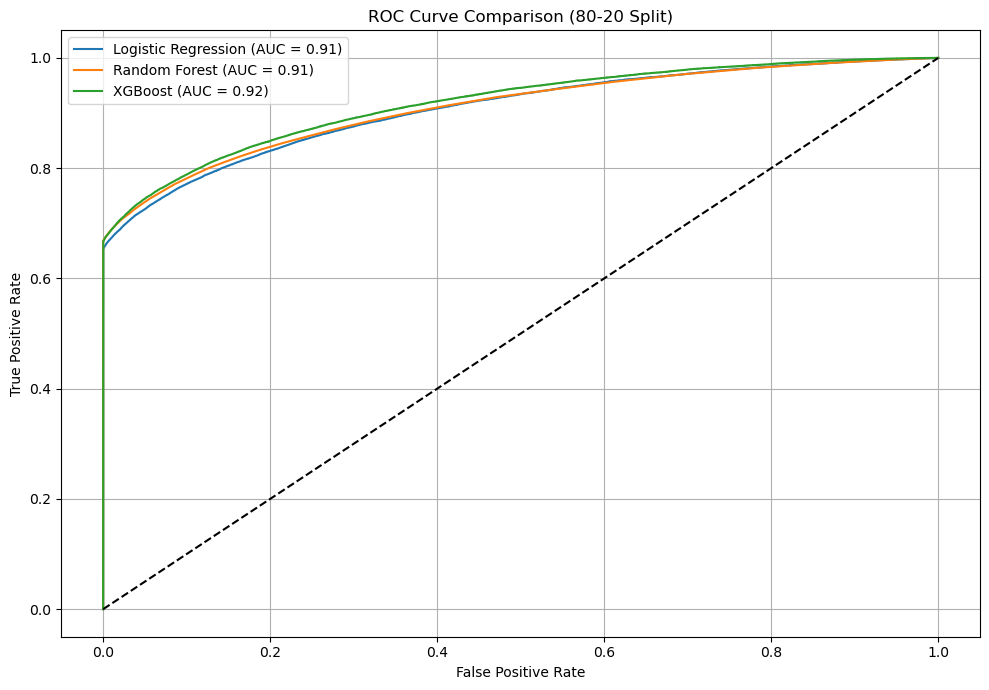

In [21]:
X_pd = df.drop(columns=['default', 'lgd', 'ead'])
y_pd = df['default']

X_train_pd, X_test_pd, y_train_pd, y_test_pd = train_test_split(
    X_pd, y_pd, test_size=0.2, stratify=y_pd, random_state=42
)

ordinal_features = ['grade', 'sub_grade', 'emp_length']
nominal_features = ['purpose', 'addr_state', 'home_ownership']
numeric_features = [
     'funded_amnt', 'int_rate', 'installment', 'annual_inc',
    'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'revol_util',
    'total_acc', 'recoveries', 'term', 'months_since_issue'
]



# Build preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('ord', OrdinalEncoder(), ordinal_features),
    ('ohe', OneHotEncoder(drop='first'), nominal_features),
    ('num', StandardScaler(), numeric_features)
])

# Models to evaluate
pd_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42)
}


plt.figure(figsize=(10, 7))
results = {}

# Loop through models
for name, model in pd_models.items():
    print(f"\n {name} : ")
    
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Train on training set
    pipeline.fit(X_train_pd, y_train_pd)
    
    # Predict probabilities on test set
    y_test_pd_pred = pipeline.predict(X_test_pd)
    y_test_pd_prob = pipeline.predict_proba(X_test_pd)[:, 1]
    
    # Compute AUC
    acc = accuracy_score(y_test_pd, y_test_pd_pred)
    prec = precision_score(y_test_pd, y_test_pd_pred, zero_division=0)
    rec = recall_score(y_test_pd, y_test_pd_pred)
    f1 = f1_score(y_test_pd, y_test_pd_pred)
    
    auc = roc_auc_score(y_test_pd, y_test_pd_prob)
    brier_score = brier_score_loss(y_test_pd, y_test_pd_prob)

    results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'AUC': auc,
        'BrierScore': brier_score
    }
    
    print(classification_report(y_test_pd, y_test_pd_pred, digits=4))

    fpr, tpr, _ = roc_curve(y_test_pd, y_test_pd_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison (80-20 Split)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



In [22]:
print(pd.DataFrame(results))

            Logistic Regression  Random Forest   XGBoost
Accuracy               0.930112       0.933165  0.932782
Precision              0.997394       0.998373  0.995282
Recall                 0.654107       0.668673  0.668847
F1 Score               0.790072       0.800920  0.800047
AUC                    0.906806       0.909543  0.917534
BrierScore             0.060400       0.058368  0.057421


1. XGBoost achieved the highest AUC and lowest Brier score, indicating it is the best calibrated and most discriminative model.

2. Random Forest delivered the best precision and F1 score, slightly outperforming others in overall classification accuracy.

3. Logistic Regression, while slightly behind in predictive performance, offers interpretability and simplicity, which is valuable in regulated environments.

## LGD modeling

In [24]:


X_lgd = df[df['default'] == 1].drop(columns=['default', 'lgd', 'ead'])
y_lgd = df[df['default'] == 1]['lgd']

X_train_lgd, X_test_lgd, y_train_lgd, y_test_lgd = train_test_split(
    X_lgd, y_lgd, test_size=0.2, random_state=42
)


ordinal_features = ['grade', 'sub_grade', 'emp_length']
nominal_features = ['purpose', 'addr_state', 'home_ownership']
numeric_features = [
     'funded_amnt', 'int_rate', 'installment', 'annual_inc', 'recoveries',
    'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'revol_util',
    'total_acc', 'term', 'months_since_issue'
]

preprocessor = ColumnTransformer(transformers=[
    ('ord', OrdinalEncoder(), ordinal_features),
    ('ohe', OneHotEncoder(drop='first'), nominal_features),
    ('num', StandardScaler(), numeric_features)
])

lgd_models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}


for name, model in lgd_models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    pipeline.fit(X_train_lgd, y_train_lgd)
    y_test_lgd_pred = pipeline.predict(X_test_lgd).clip(0, 1)
    
    print(f"\n{name}:")
    print("  RMSE:", mean_squared_error(y_test_lgd, y_test_lgd_pred, squared=False))
    print("  R-squared:", r2_score(y_test_lgd, y_test_lgd_pred))


Linear Regression:
  RMSE: 0.04669743175508099
  R-squared: 0.7683130487235765

Random Forest:
  RMSE: 0.0031873346602551873
  R-squared: 0.99892062858238


We modeled Loss Given Default (LGD) using both linear and nonlinear regression techniques. Since LGD is defined using recoveries, we included recoveries as an explanatory feature. Linear regression achieved an $R^2$ of 0.77, while Random Forest outperformed with an $R^2$ of 0.99 and RMSE close to 0, indicating its strong ability to model the non-linear relationship between loan characteristics and LGD.

## EAD modeling

In [25]:
# Filter defaulted loans only
X_ead = df[df['default'] == 1].drop(columns=['default', 'lgd', 'ead', 'funded_amnt', 'recoveries'])
y_ead = df[df['default'] == 1]['ead']

ordinal_features = ['grade', 'sub_grade', 'emp_length']
nominal_features = ['purpose', 'addr_state', 'home_ownership']
numeric_features = [
     'int_rate', 'annual_inc',  'installment',
    'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'revol_util',
    'total_acc', 'term', 'months_since_issue'
]
# Build preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('ord', OrdinalEncoder(), ordinal_features),
    ('ohe', OneHotEncoder(drop='first'), nominal_features),
    ('num', StandardScaler(), numeric_features)
])

# 80-20 split
X_train_ead, X_test_ead, y_train_ead, y_test_ead = train_test_split(
    X_ead, y_ead, test_size=0.2, random_state=42
)

# Define models
ead_models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(eval_metric='rmse', random_state=42, n_jobs=-1)
}

# Store results
ead_results = []

for name, model in ead_models.items():
    # Pipeline
    ead_pipeline = Pipeline([
        ('preprocess', preprocessor),
        ('model', model)
    ])

    # Fit and predict
    ead_pipeline.fit(X_train_ead, y_train_ead)
    preds = ead_pipeline.predict(X_test_ead)
    y_test_ead_pred = np.clip(preds, 0, None)  # Clip to non-negative

    # Evaluation
    rmse = mean_squared_error(y_test_ead, y_test_ead_pred, squared=False)
    r2 = r2_score(y_test_ead, y_test_ead_pred)

    ead_results.append({
        'model': name,
        'rmse': rmse,
        'r2': r2
    })

# Convert to DataFrame and display
ead_results_df = pd.DataFrame(ead_results)
print("\nEAD Model Evaluation (80-20 split):")
print(ead_results_df.sort_values('rmse'))


EAD Model Evaluation (80-20 split):
               model         rmse        r2
1      Random Forest    58.748339  0.999955
2            XGBoost   144.399145  0.999730
0  Linear Regression  1266.926443  0.979231


Random Forest achieved the best performance, indicating its superior ability to capture complex, nonlinear relationships between borrower characteristics and EAD. Linear Regression, while still reasonably good, underperformed compared to tree-based models.

## Expected loss and credit vaR

For simplicity and interpretability, we use Logistic Regression for the Probability of Default (PD) model, and Linear Regression for both the Exposure at Default (EAD) and Loss Given Default (LGD) models. These models are trained on the full dataset and used to compute portfolio-level Expected Loss and Credit Value at Risk (Credit VaR).

1. PD computation

In [26]:
X_pd = df.drop(columns=['default', 'lgd', 'ead'])
y_pd = df['default']

ordinal_features = ['grade', 'sub_grade', 'emp_length']
nominal_features = ['purpose', 'addr_state', 'home_ownership']
numeric_features = [
     'funded_amnt', 'int_rate', 'installment', 'annual_inc',
    'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'revol_util',
    'total_acc', 'recoveries', 'term', 'months_since_issue'
]


preprocessor = ColumnTransformer(transformers=[
    ('ord', OrdinalEncoder(), ordinal_features),
    ('ohe', OneHotEncoder(drop='first'), nominal_features),
    ('num', StandardScaler(), numeric_features)
])


pd_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000))
    ])

pd_pipeline.fit(X_pd, y_pd)
    
# Predict probabilities on test set
y_pd_pred = pd_pipeline.predict(X_pd)
y_pd_prob = pd_pipeline.predict_proba(X_pd)[:, 1]


2. LGD computation

In [27]:

X_lgd = df.drop(columns=['default', 'lgd', 'ead'])
y_lgd = df['lgd']

ordinal_features = ['grade', 'sub_grade', 'emp_length']
nominal_features = ['purpose', 'addr_state', 'home_ownership']
numeric_features = [
     'funded_amnt', 'int_rate', 'installment', 'annual_inc', 'recoveries',
    'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'revol_util',
    'total_acc', 'term', 'months_since_issue'
]

preprocessor = ColumnTransformer(transformers=[
    ('ord', OrdinalEncoder(), ordinal_features),
    ('ohe', OneHotEncoder(drop='first'), nominal_features),
    ('num', StandardScaler(), numeric_features)
])

    
lgd_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ])
    
lgd_pipeline.fit(X_lgd, y_lgd)
y_lgd_pred = pipeline.predict(X_lgd).clip(0, 1)


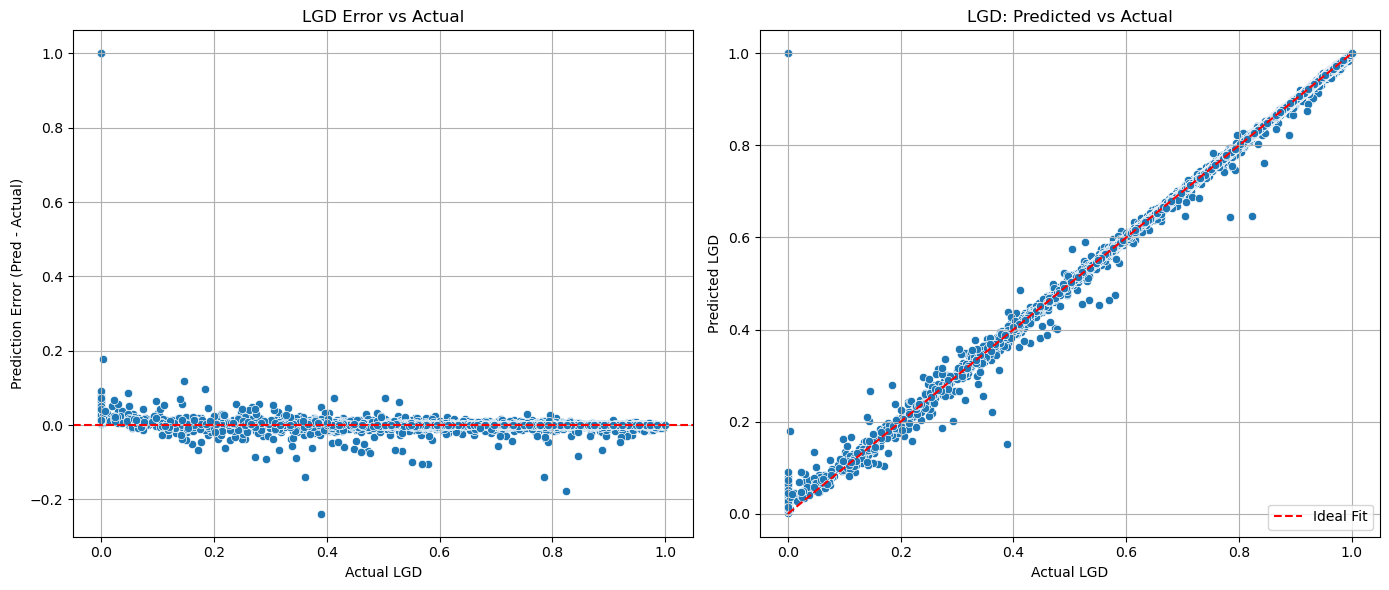

In [60]:
error = y_lgd_pred - y_lgd

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Error vs Actual
sns.scatterplot(x=y_lgd, y=error, ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title("LGD: Error vs Actual")
axes[0].set_xlabel("Actual LGD")
axes[0].set_ylabel("Prediction Error (Pred - Actual)")
axes[0].grid(True)

# 2. Predicted vs Actual
sns.scatterplot(x=y_lgd, y=y_lgd_pred, ax=axes[1])
min_val = min(y_lgd.min(), y_lgd_pred.min())
max_val = max(y_lgd.max(), y_lgd_pred.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal Fit')
axes[1].set_title("LGD: Predicted vs Actual")
axes[1].set_xlabel("Actual LGD")
axes[1].set_ylabel("Predicted LGD")
axes[1].legend()
axes[1].grid(True)


plt.tight_layout()
plt.show()

3.  EAD computation

In [28]:

X_ead = df.drop(columns=['default', 'lgd', 'ead', 'funded_amnt', 'recoveries'])
y_ead = df['ead']

ordinal_features = ['grade', 'sub_grade', 'emp_length']
nominal_features = ['purpose', 'addr_state', 'home_ownership']
numeric_features = [
     'int_rate', 'annual_inc',  'installment',
    'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'revol_util',
    'total_acc', 'term', 'months_since_issue'
]

preprocessor = ColumnTransformer(transformers=[
    ('ord', OrdinalEncoder(), ordinal_features),
    ('ohe', OneHotEncoder(drop='first'), nominal_features),
    ('num', StandardScaler(), numeric_features)
])


ead_pipeline = Pipeline([
        ('preprocess', preprocessor),
        ('model', LinearRegression())
    ])

ead_pipeline.fit(X_ead, y_ead)
preds = ead_pipeline.predict(X_ead)
y_ead_pred = np.clip(preds, 0, None)  # Clip to non-negative


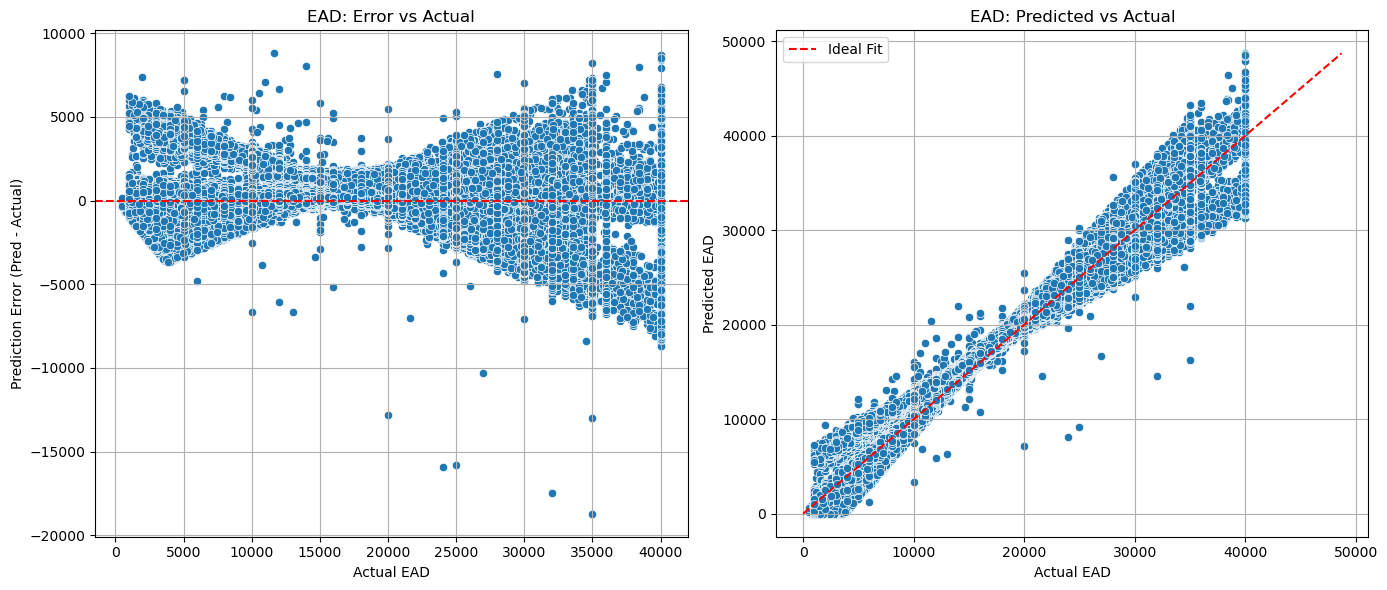

In [66]:
error = y_ead_pred - y_ead

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Error vs Actual
sns.scatterplot(x=y_ead, y=error, ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title("EAD: Error vs Actual")
axes[0].set_xlabel("Actual EAD")
axes[0].set_ylabel("Prediction Error (Pred - Actual)")
axes[0].grid(True)

# Predicted vs Actual
sns.scatterplot(x=y_ead, y=y_ead_pred, ax=axes[1])
min_val = min(y_ead.min(), y_ead_pred.min())
max_val = max(y_ead.max(), y_ead_pred.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal Fit')
axes[1].set_title("EAD: Predicted vs Actual")
axes[1].set_xlabel("Actual EAD")
axes[1].set_ylabel("Predicted EAD")
axes[1].legend()
axes[1].grid(True)


plt.tight_layout()
plt.show()

In [29]:
expected_loss_arr = y_pd_prob * y_lgd_pred * y_ead_pred

In [30]:
analytical_EL = sum(expected_loss_arr)
print(f"Expected Loss (analytical) is {analytical_EL:.2f}")

Expected Loss (analytical) is 2913797768.02


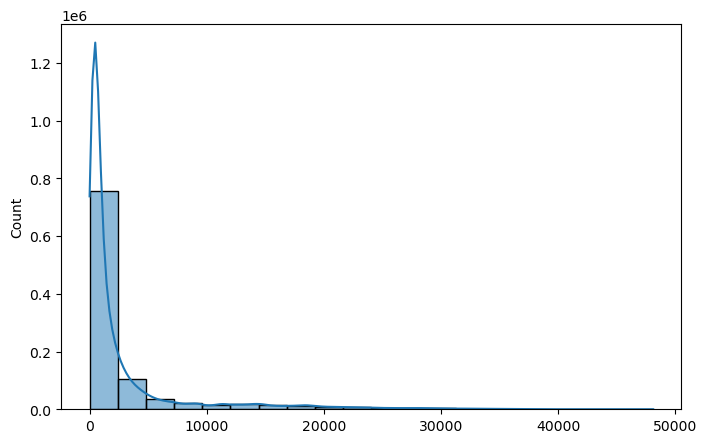

In [31]:
plt.figure(figsize=(8,5))
sns.histplot(expected_loss_arr, bins=20, kde=True)
plt.show()

Simulation of loss

In [33]:
n_simulations = 1000
batch_size = 100  
n_loans = len(y_pd_prob)

n_batches = n_simulations // batch_size
losses = []

for _ in range(n_batches):
    # Simulate (n_loans x batch_size) default indicators
    default_matrix = np.random.binomial(1, y_pd_prob[:, np.newaxis], size=(n_loans, batch_size))

    # Loss matrix: elementwise multiply
    loss_matrix = default_matrix * y_lgd_pred[:, np.newaxis] * y_ead_pred[:, np.newaxis]

    # Sum over loans to get portfolio loss per simulation
    batch_losses = np.sum(loss_matrix, axis=0)
    losses.append(batch_losses)

# Concatenate all batches
losses = np.concatenate(losses)


In [34]:
expected_loss_sim = np.mean(losses)
credit_var_99 = np.percentile(losses, 99)
credit_var_99_unexpected = credit_var_99 - expected_loss_sim

print(f"Expected Loss (simulation): {expected_loss_sim:.2f}")
print(f"99% Credit VaR (Total): {credit_var_99:.2f}")
print(f"99% Unexpected Loss: {credit_var_99_unexpected:.2f}")


Expected Loss (simulation): 2913766862.95
99% Credit VaR (Total): 2924484992.09
99% Unexpected Loss: 10718129.14


In [35]:
print(f"Error rate is {(abs(expected_loss_sim - analytical_EL) / analytical_EL)*100:.3f}%")

Error rate is 0.001%


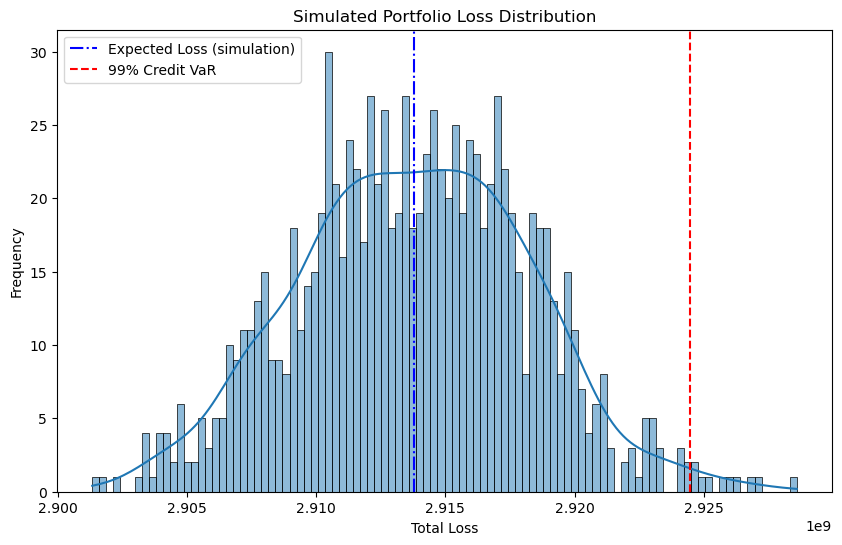

In [36]:

plt.figure(figsize=(10,6))
sns.histplot(losses, bins=100, kde=True)
plt.axvline(expected_loss_sim, color='blue', linestyle='-.', label='Expected Loss (simulation)')
#plt.axvline(X_test["expected_loss"].sum(), color='black', linestyle='-', label='Expected Loss (analytical)')
plt.axvline(credit_var_99, color='red', linestyle='--', label='99% Credit VaR')
plt.legend()
plt.title('Simulated Portfolio Loss Distribution')
plt.xlabel('Total Loss')
plt.ylabel('Frequency')
plt.show()


## Scorecard building

[INFO] creating woe binning ...
Binning on 1003892 rows and 20 columns in 00:00:34


{'home_ownership': <Figure size 640x480 with 2 Axes>,
 'term': <Figure size 640x480 with 2 Axes>,
 'purpose': <Figure size 640x480 with 2 Axes>,
 'dti': <Figure size 640x480 with 2 Axes>,
 'addr_state': <Figure size 640x480 with 2 Axes>,
 'revol_util': <Figure size 640x480 with 2 Axes>,
 'delinq_2yrs': <Figure size 640x480 with 2 Axes>,
 'sub_grade': <Figure size 640x480 with 2 Axes>,
 'installment': <Figure size 640x480 with 2 Axes>,
 'int_rate': <Figure size 640x480 with 2 Axes>,
 'months_since_issue': <Figure size 640x480 with 2 Axes>,
 'total_acc': <Figure size 640x480 with 2 Axes>,
 'emp_length': <Figure size 640x480 with 2 Axes>,
 'recoveries': <Figure size 640x480 with 2 Axes>,
 'funded_amnt': <Figure size 640x480 with 2 Axes>,
 'annual_inc': <Figure size 640x480 with 2 Axes>,
 'grade': <Figure size 640x480 with 2 Axes>,
 'open_acc': <Figure size 640x480 with 2 Axes>,
 'inq_last_6mths': <Figure size 640x480 with 2 Axes>}

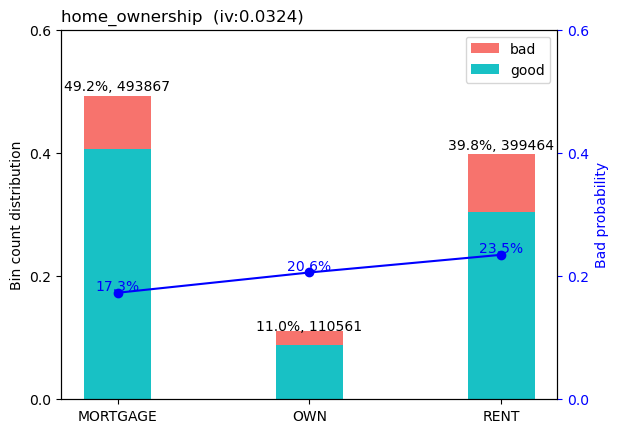

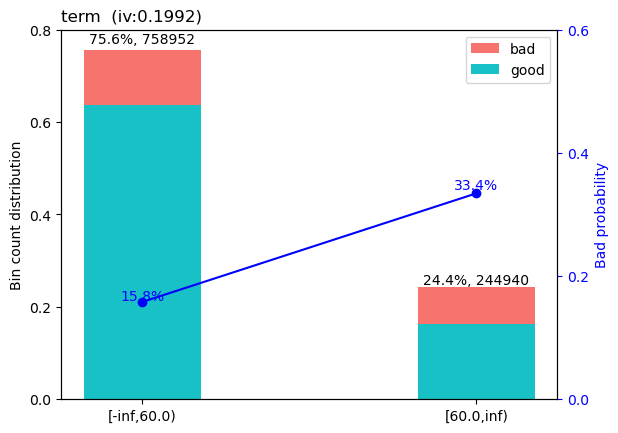

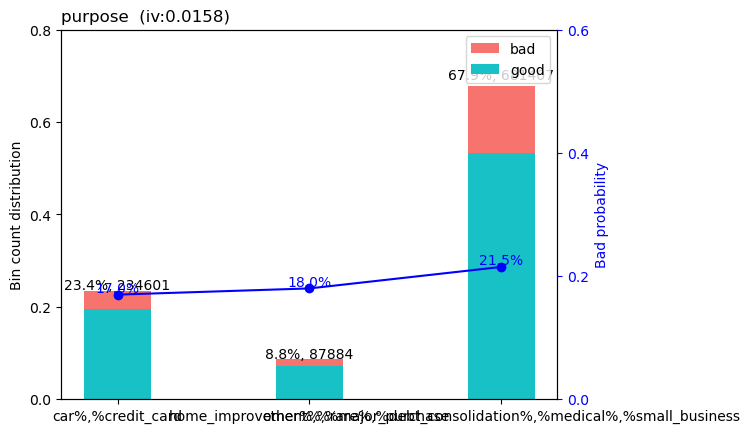

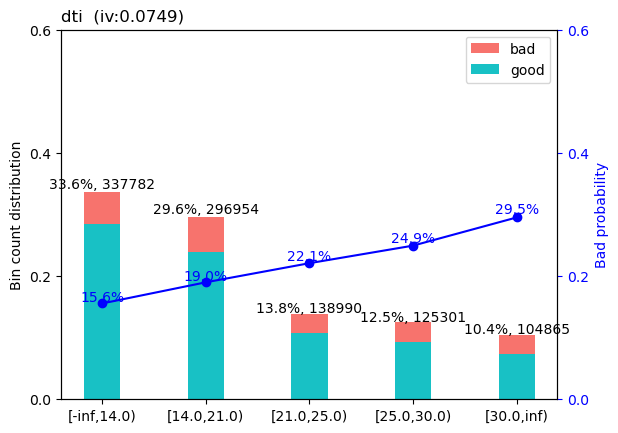

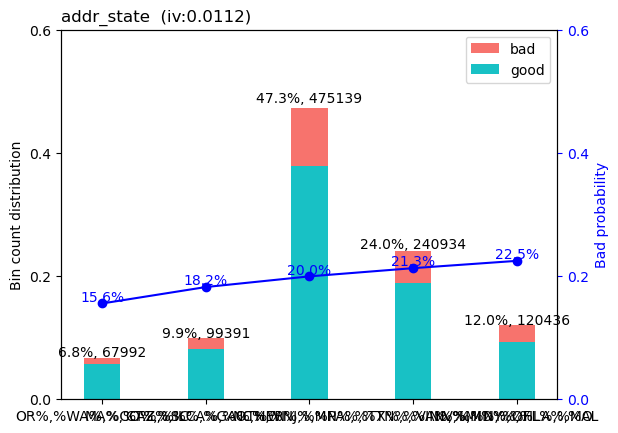

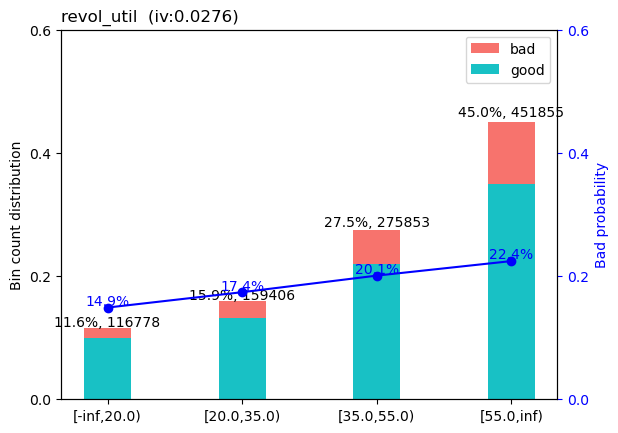

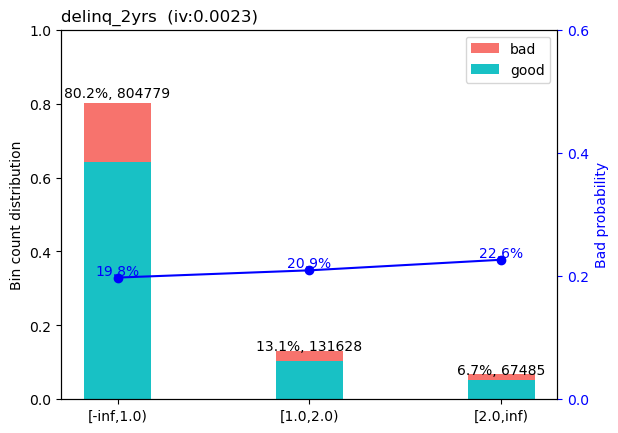

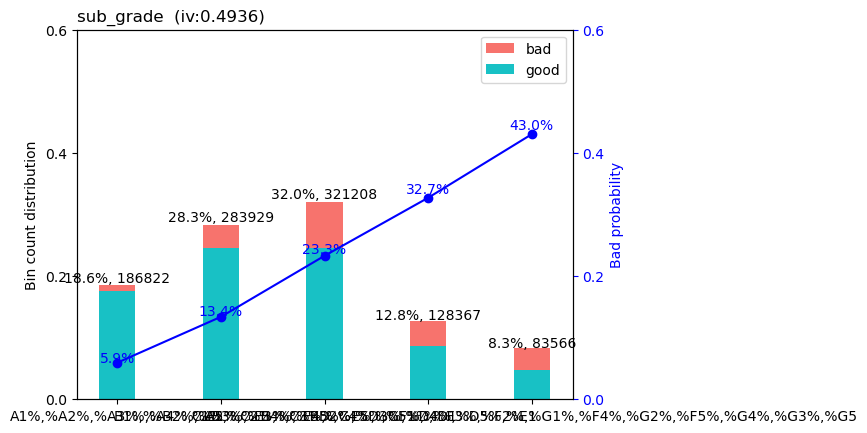

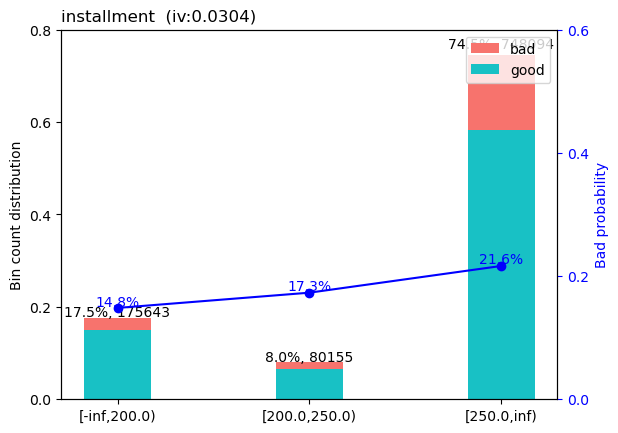

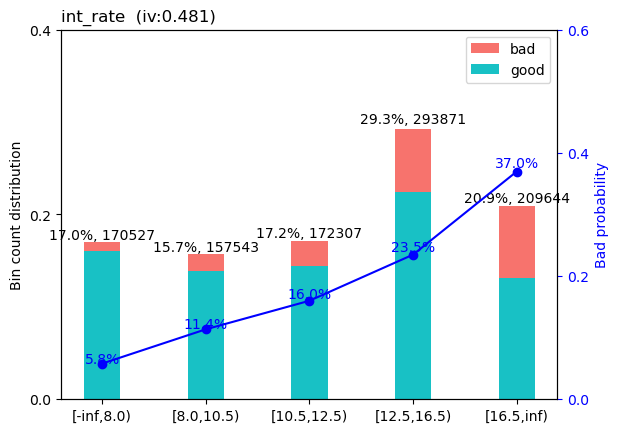

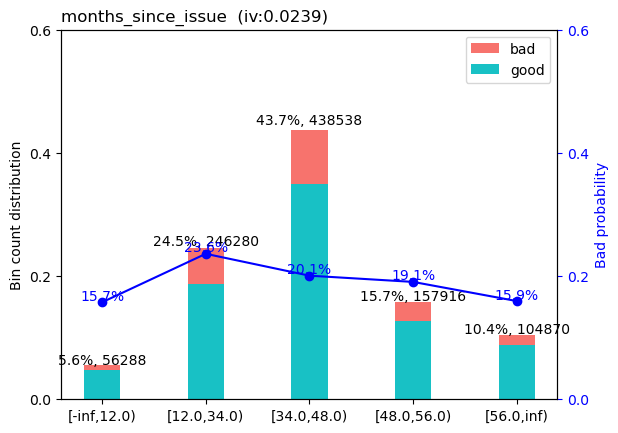

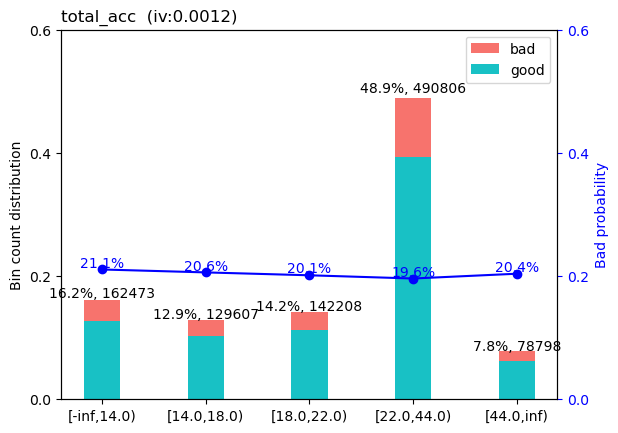

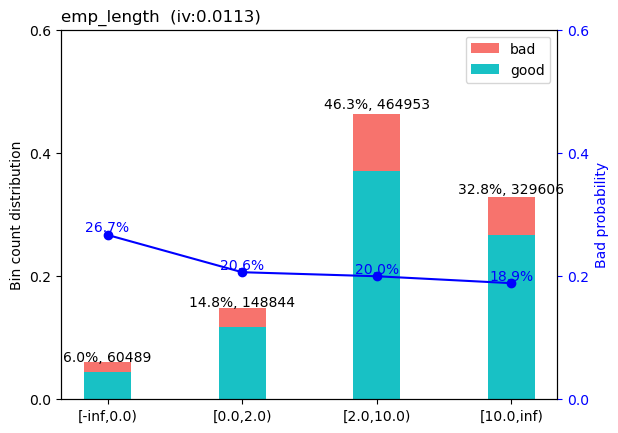

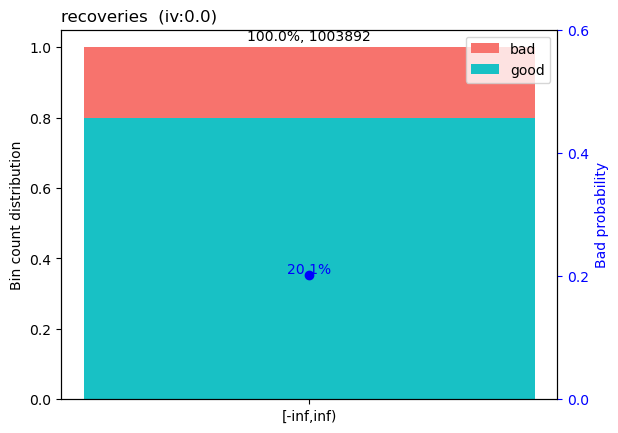

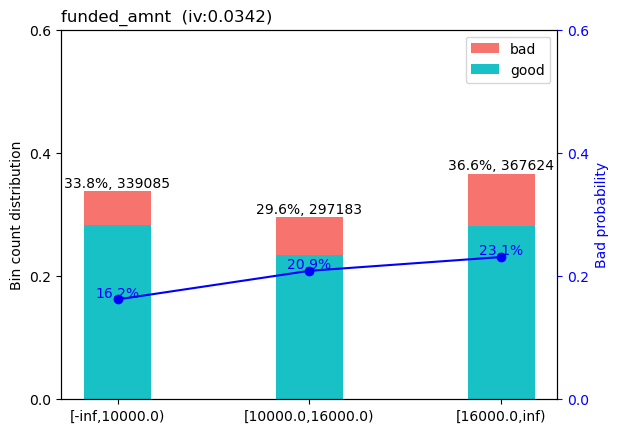

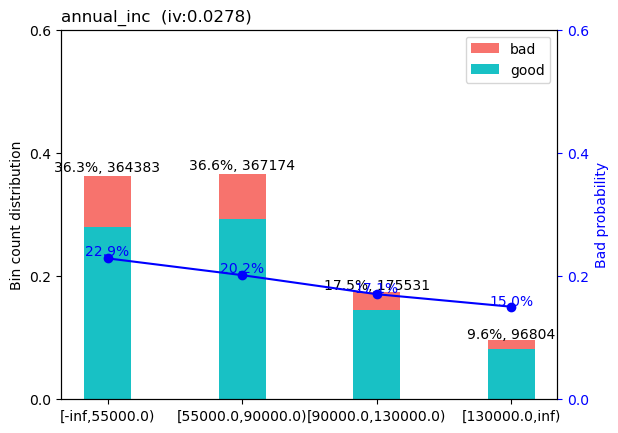

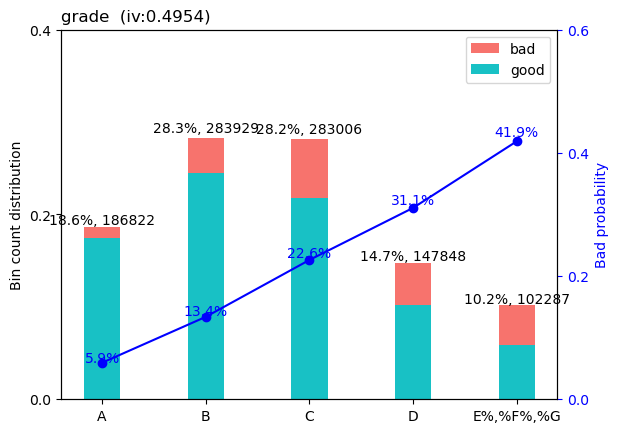

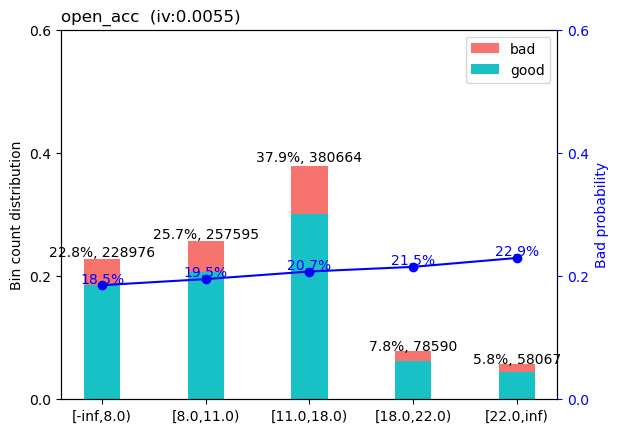

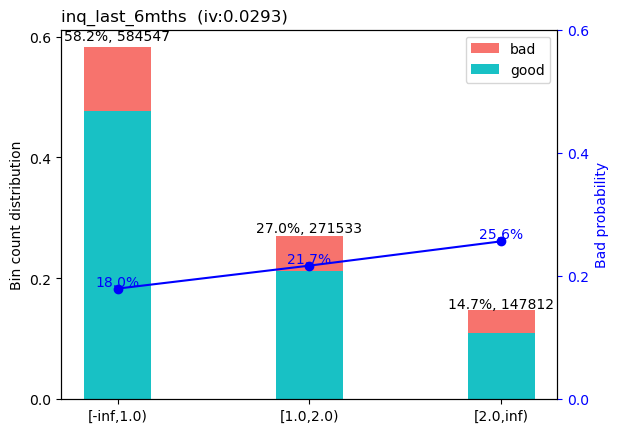

In [37]:

bins = woebin(df.drop(columns= ['lgd', 'ead']), y='default')
woebin_plot(bins)


In [38]:

df_woe = woebin_ply(df.drop(columns= ['lgd', 'ead']), bins)


[INFO] converting into woe values ...
Woe transformating on 1003892 rows and 19 columns in 00:00:24


In [39]:


X_woe = df_woe.drop(columns=['default'])
y_woe = df_woe['default']

X_train_woe, X_test_woe, y_train_woe, y_test_woe = train_test_split(X_woe, y_woe, stratify=y_woe, random_state=42)

model = LogisticRegression()
model.fit(X_train_woe, y_train_woe)

# Evaluate
print("AUC:", roc_auc_score(y_test_woe, model.predict_proba(X_test_woe)[:, 1]))


AUC: 0.722994953882649


In [40]:

# Assume:
score_odds = 600  # base score
pdo = 50          # points to double the odds
p_bad = y_test_woe.mean()  # or your full data's mean
base_odds = p_bad / (1 - p_bad)
factor = pdo / np.log(2)
offset = score_odds + factor * np.log(base_odds)
log_odds = model.decision_function(X_test_woe)  # if 1 is default
scores = offset - factor * log_odds



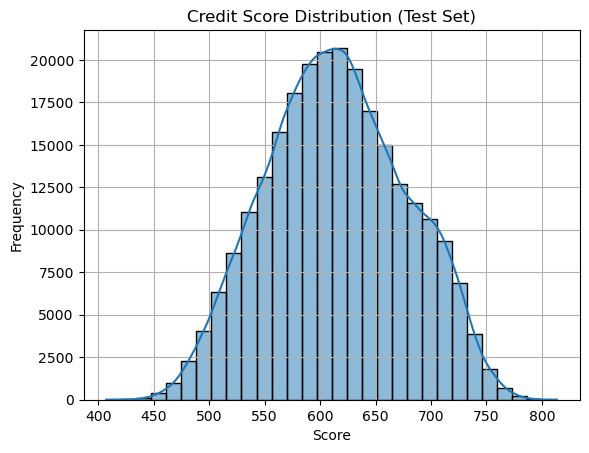

In [41]:


sns.histplot(scores, bins=30, kde=True)
plt.title('Credit Score Distribution (Test Set)')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


In [42]:
df_test = X_test_woe.copy()
df_test['default'] = y_test_woe.values
df_test['score'] = scores

# Bin into deciles or fixed-width buckets
df_test['score_bin'] = pd.qcut(df_test['score'], q=10)
df_test['score_bin'] = df_test['score_bin'].apply(
    lambda x: f"{round(x.left)}–{round(x.right)}"
)

# Group and summarize
score_summary = df_test.groupby('score_bin').agg(
    total=('default', 'count'),
    defaults=('default', 'sum')
)
score_summary['default_rate'] = score_summary['defaults'] / score_summary['total']
print(score_summary)


           total  defaults  default_rate
score_bin                               
407–532    25098     11954      0.476293
532–559    25097      8591      0.342312
559–579    25097      6931      0.276168
579–597    25097      5813      0.231621
597–613    25098      4840      0.192844
613–630    25097      3922      0.156274
630–649    25097      3163      0.126031
649–672    25097      2473      0.098538
672–702    25097      1694      0.067498
702–814    25098      1079      0.042991


<Axes: title={'center': 'Default Rate by Score Bin'}, xlabel='score_bin'>

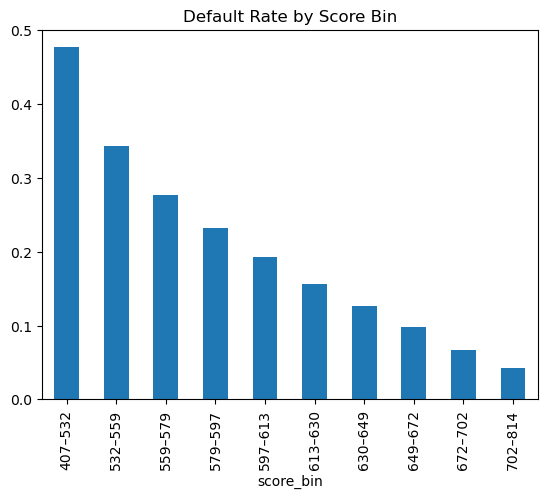

In [43]:
score_summary['default_rate'].plot(kind='bar', title='Default Rate by Score Bin')


In [78]:
cutoffs = range(400,850, 10)

results = []

for cutoff in cutoffs:
    df_test['decision'] = df_test['score'].apply(lambda x: 'accept' if x >= cutoff else 'reject')
    
    accepted = df_test[df_test['decision'] == 'accept']
    rejected = df_test[df_test['decision'] == 'reject']

    # Confusion matrix components
    TP = ((rejected['default'] == 1)).sum()  # correctly rejected defaulters
    FP = ((rejected['default'] == 0)).sum()  # wrongly rejected non-defaulters
    TN = ((accepted['default'] == 0)).sum()  # correctly accepted good customers
    FN = ((accepted['default'] == 1)).sum()  # wrongly accepted defaulters
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    results.append({
        'cutoff': cutoff,
        'accepted_count': len(accepted),
        'rejected_count': len(rejected),
        'accepted_default_rate': accepted['default'].mean(),
        'rejected_default_rate': rejected['default'].mean(),
        'TP': TP,
        'FP': FP,
        'TN': TN,
        'FN': FN,
        'approval_rate': len(accepted) / len(df_test),
        'Recall': recall
    })

cutoff_df = pd.DataFrame(results)


In [79]:
#pd.set_option("display.float_format", "{:.2%}".format)
cutoff_df

,cutoff,accepted_count,rejected_count,accepted_default_rate,rejected_default_rate,TP,FP,TN,FN,approval_rate,Recall
0,400,250973,0,0.201057,NaN,0,0,200513,50460,1.000000,0.000000
1,410,250972,1,0.201058,0.000000,0,1,200512,50460,0.999996,0.000000
2,420,250966,7,0.201039,0.857143,6,1,200512,50454,0.999972,0.000119
3,430,250956,17,0.201019,0.764706,13,4,200509,50447,0.999932,0.000258
4,440,250927,46,0.200963,0.717391,33,13,200500,50427,0.999817,0.000654
5,450,250826,147,0.200789,0.659864,97,50,200463,50363,0.999414,0.001922
6,460,250529,444,0.200256,0.653153,290,154,200359,50170,0.998231,0.005747
7,470,249924,1049,0.199253,0.631077,662,387,200126,49798,0.995820,0.013119
8,480,248757,2216,0.197410,0.610560,1353,863,199650,49107,0.991170,0.026813
9,490,246790,4183,0.194428,0.592159,2477,1706,198807,47983,0.983333,0.049088


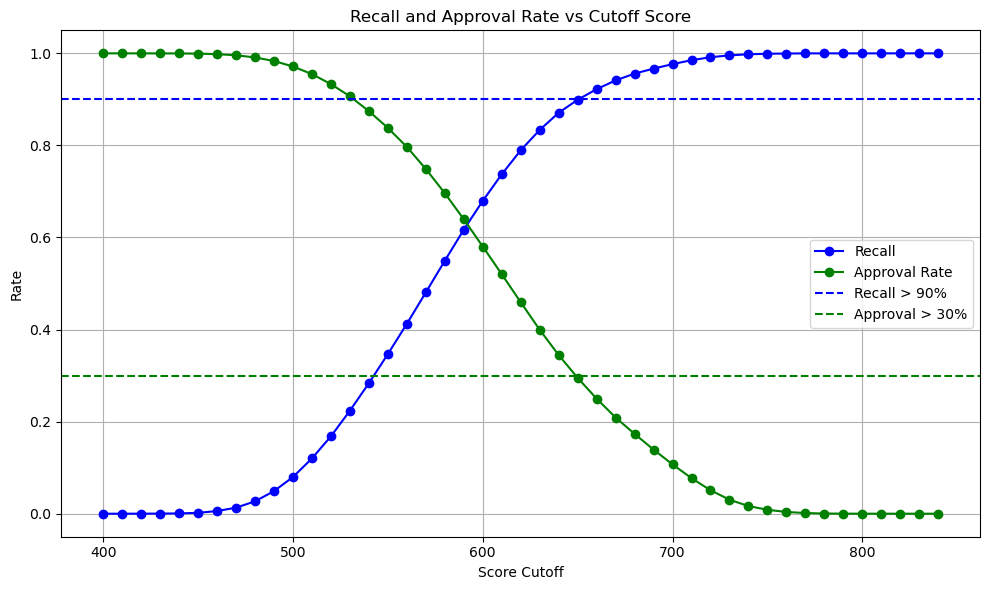

In [80]:
plt.figure(figsize=(10, 6))
plt.plot(cutoff_df['cutoff'], cutoff_df['Recall'], label='Recall', color='blue', marker='o')
plt.plot(cutoff_df['cutoff'], cutoff_df['approval_rate'], label='Approval Rate', color='green', marker='o')
plt.axhline(0.90, color='blue', linestyle='--', label='Recall > 90%')
plt.axhline(0.30, color='green', linestyle='--', label='Approval > 30%')

plt.xlabel('Score Cutoff')
plt.ylabel('Rate')
plt.title('Recall and Approval Rate vs Cutoff Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Score cutoff 650 is a good cutoff as Recall ~ 90% and Approval ~30%.

Confusion Matrix (Cutoff = 650):
[[ 68964. 131549.]
 [  5087.  45373.]]


Text(0.5, 1.0, 'Confusion Matrix (Score Cutoff = 650)')

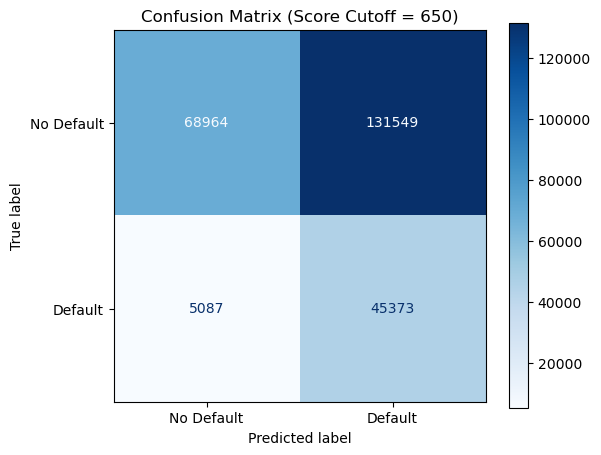

In [87]:
cutoff_650 = cutoff_df[cutoff_df['cutoff'] == 650].iloc[0]

cm = np.array([
    [cutoff_650['TN'], cutoff_650['FP']],  # [TN, FP]
    [cutoff_650['FN'], cutoff_650['TP']]   # [FN, TP]
])

print("Confusion Matrix (Cutoff = 650):")
print(cm)



fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', values_format='.0f')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Default", "Default"])
plt.title("Confusion Matrix (Score Cutoff = 650)")
plt.title("Confusion Matrix (Score Cutoff = 650)")
